# 两层全连接神经网络底层实现
## 实验概述
从零实现两层全连接神经网络，包含前向传播、反向传播、SGD训练与超参调优，在CIFAR-10图像数据集上完成分类任务验证。

In [ ]:
from __future__ import print_function
import numpy as np
import matplotlib.pyplot as plt
from pylab import mpl
mpl.rcParams['font.sans-serif'] = ['SimHei']
from classifiers.neural_net_注释详解版 import TwoLayerNet

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # 设置plots的默认尺寸
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# 自动加载模型
%load_ext autoreload
%autoreload 2

# 返回相对误差
def rel_error(x, y):
    # 公式: rel_error = |x-y| / max(1e-8,|x|+|y|)
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

网络结构实现在 `classifiers/neural_net.py` 的 `TwoLayerNet` 类中，所有权重与偏置参数存储在`self.params`字典中。首先构造小规模模拟数据，验证网络前向与反向实现的正确性。

In [2]:
# 创建一个小的网络及一些模拟的数据，用以检查我们的代码实现
# 设置随机种子保证实验可复现
input_size = 4   # 输入特征维度（例如：每个样本有4个特征）
hidden_size = 10 # 隐藏层神经元数量
num_classes = 3  # 分类类别数（例如：分3类）
num_inputs = 5   # 样本数量（一共有5个数据样本）

# 初始化模型
def init_toy_model():
    np.random.seed(0)
    return TwoLayerNet(input_size, hidden_size, num_classes, std=1e-1) # std=1e-1：控制权重初始化的尺度，防止权重过大或过小导致训练不稳定

# 生成模拟数据
def init_toy_data():
    np.random.seed(1)
    # 生成样本（5个样本，每个样本4个特征），浮点数组，取数范围：正态分布的随机数（均值0，方差1）
    X = 10 * np.random.randn(num_inputs, input_size)  # * 10：放大数值范围，增加数据区分度
    # 生成标签
    y = np.array([0, 1, 2, 2, 1])
    return X, y

# 初始化模型和数据
net = init_toy_model()
X, y = init_toy_data()
# 遍历每一个样本，打印查看数据内容
for xi, yi in zip(X, y):
    print(xi, '->', yi)

[ 16.24345364  -6.11756414  -5.28171752 -10.72968622] -> 0
[  8.65407629 -23.01538697  17.44811764  -7.61206901] -> 1
[  3.19039096  -2.49370375  14.62107937 -20.60140709] -> 2
[ -3.22417204  -3.84054355  11.33769442 -10.99891267] -> 2
[-1.72428208 -8.77858418  0.42213747  5.82815214] -> 1


### 前向传播：计算分类得分
`TwoLayerNet.loss` 方法集成前向得分计算、损失计算与反向梯度推导。首先完成前向传播逻辑，基于两层权重与偏置计算输入样本的分类得分。

In [3]:
scores = net.loss(X)
print('计算得分:\n', scores)
print('正确得分:')
correct_scores = np.asarray([
  [-0.81233741, -1.27654624, -0.70335995],
  [-0.17129677, -1.18803311, -0.47310444],
  [-0.51590475, -1.01354314, -0.8504215 ],
  [-0.15419291, -0.48629638, -0.52901952],
  [-0.00618733, -0.12435261, -0.15226949]])
print(correct_scores)

# 结果差异应小于1e-7，验证实现正确性
print('计算得分与正确得分之间的差异:')
print(np.sum(np.abs(scores - correct_scores)))

计算得分:
 [[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]
正确得分:
[[-0.81233741 -1.27654624 -0.70335995]
 [-0.17129677 -1.18803311 -0.47310444]
 [-0.51590475 -1.01354314 -0.8504215 ]
 [-0.15419291 -0.48629638 -0.52901952]
 [-0.00618733 -0.12435261 -0.15226949]]
计算得分与正确得分之间的差异:
3.6802720745909845e-08


### 前向传播：计算损失
基于分类得分完成Softmax交叉熵损失计算，叠加L2正则化项，得到最终总损失。

In [4]:
loss, _ = net.loss(X, y, reg=0.05)
correct_loss = 1.30378789133
print('你计算的损失:')
print(loss)
print('正确的损失:')
print(correct_loss)
# 差异应该非常小， < 1e-12
print('你计算的损失与正确损失的差异:')
print(np.sum(np.abs(loss - correct_loss)))

你计算的损失:
1.2848224717239367
正确的损失:
1.30378789133
你计算的损失与正确损失的差异:
0.01896541960606335


### 反向传播：计算参数梯度
基于链式法则逐层反向推导，计算W1、b1、W2、b2的解析梯度，通过数值梯度校验反向实现的正确性，两者差异应小于1e-8。

In [5]:
from datasets.gradient_check import eval_numerical_gradient
# 使用数值梯度检查反向代码
# 如果代码正确，在W1, W2, b1, 以及 b2 上的数值梯度与解析梯度的差异应该小于 1e-8 .

loss, grads = net.loss(X, y, reg=0.05)

# 与数值梯度比较，所有的差异都应该差不多小于 1e-8
for param_name in grads:
    #计算数值梯度的函数为损失函数，固定X，y及net对象的其他初始化值，接收留意参数作为变量，求得损失
    f = lambda W: net.loss(X, y, reg=0.05)[0]
    param_grad_num = eval_numerical_gradient(f, net.params[param_name], verbose=False)
    print('d%s 最大相对差异: %e' % (param_name, rel_error(param_grad_num, grads[param_name])))    
    #print('数值%s' % (param_grad_num))
    #print('解析%s' % (grads[param_name]))

dW2 最大相对差异: 3.440708e-09
db2 最大相对差异: 4.447625e-11
dW1 最大相对差异: 3.561318e-09
db1 最大相对差异: 2.738421e-09


### 小规模数据训练验证
基于小批量SGD实现模型训练，逻辑封装在 `TwoLayerNet.train` 方法中，配套`predict`方法完成分类预测。首先在模拟数据上验证训练流程的正确性，损失应收敛至0.2以下。

In [ ]:
net = init_toy_model()
stats = net.train(X, y, X, y, learning_rate=1e-1, reg=5e-6, num_iters=100, verbose=False)
print('最后的训练损失: ', stats['loss_history'][-1])

# 绘制训练损失下降曲线
plt.plot(stats['loss_history'])
plt.xlabel('iteration')
plt.ylabel('training loss')
plt.title('Training Loss history')
plt.show()

### CIFAR-10数据集加载与预处理
模拟数据验证通过后，加载真实CIFAR-10图像数据集，完成数据拆分、均值中心化与特征展平等预处理操作，用于真实场景的模型训练。

In [7]:
from datasets.data_utils import load_CIFAR10

# 加载 CIFAR-10 数据集，执行预处理，为两层神经网络分类器做准备
def get_CIFAR10_data(num_training=49000, num_validation=1000, num_test=1000):
    # 加载原始的 CIFAR-10 数据
    cifar10_dir = '../datasets/cifar-10-batches-py'
    
    X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)
        
    # 拆分数据
    mask = list(range(num_training, num_training + num_validation))
    X_val = X_train[mask]
    y_val = y_train[mask]
    mask = list(range(num_training))
    X_train = X_train[mask]
    y_train = y_train[mask]
    mask = list(range(num_test))
    X_test = X_test[mask]
    y_test = y_test[mask]

    # 规范化: 减去平均值
    mean_image = np.mean(X_train, axis=0)
    X_train -= mean_image
    X_val -= mean_image
    X_test -= mean_image

    # 预处理：将数据转换为一行
    X_train = X_train.reshape(num_training, -1)
    X_val = X_val.reshape(num_validation, -1)
    X_test = X_test.reshape(num_test, -1)

    return X_train, y_train, X_val, y_val, X_test, y_test


# 清除变量，防止多次加载数据(耗内存)
try:
   del X_train, y_train
   del X_test, y_test
   print('清除先前加载的数据')
except:
   pass

# 调用上述方法取得数据，看看是否合理
X_train, y_train, X_val, y_val, X_test, y_test = get_CIFAR10_data()
print('训练数据 shape: ', X_train.shape)
print('训练标签 shape: ', y_train.shape)
print('验证数据 shape: ', X_val.shape)
print('验证标签 shape: ', y_val.shape)
print('测试数据 shape: ', X_test.shape)
print('测试标签 shape: ', y_test.shape)

训练数据 shape:  (49000, 3072)
训练标签 shape:  (49000,)
验证数据 shape:  (1000, 3072)
验证标签 shape:  (1000,)
测试数据 shape:  (1000, 3072)
测试标签 shape:  (1000,)


### 真实数据集训练
采用小批量SGD算法训练网络，加入学习率衰减策略，每轮epoch按比例下调学习率，提升训练稳定性。

In [8]:
input_size = 32 * 32 * 3
hidden_size = 50
num_classes = 10
net = TwoLayerNet(input_size, hidden_size, num_classes)

# 训练网络
stats = net.train(X_train, y_train, X_val, y_val,
            num_iters=1000, batch_size=200,
            learning_rate=1e-4, learning_rate_decay=0.95,
            reg=0.25, verbose=True)

# 在验证集上预测
val_acc = (net.predict(X_val) == y_val).mean()
print('在验证集上的准确率: ', val_acc)

Failed to read module file 'D:\Python学习\PythonDL\datasets\data_utils.py' for module 'datasets.data_utils': UnicodeDecodeError
Traceback (most recent call last):
  File "D:\Python解释器\.venv\Lib\site-packages\IPython\extensions\deduperreload\deduperreload.py", line 219, in update_sources
    self.source_by_modname[new_modname] = f.read()
                                          ~~~~~~^^
UnicodeDecodeError: 'gbk' codec can't decode byte 0xae in position 47: illegal multibyte sequence


迭代 0/1000: 损失 = 2.3028
迭代 100/1000: 损失 = 2.3024
迭代 200/1000: 损失 = 2.2974
迭代 300/1000: 损失 = 2.2589
迭代 400/1000: 损失 = 2.2030
迭代 500/1000: 损失 = 2.1168
迭代 600/1000: 损失 = 2.0498
迭代 700/1000: 损失 = 1.9857
迭代 800/1000: 损失 = 2.0037
迭代 900/1000: 损失 = 1.9481
在验证集上的准确率:  0.287


# 调试训练过程
用上述参数，在验证集上大约能得到 0.29 的准确率，这不行，太低。
我们可以用图来显示到底有什么问题，在优化过程中，显示训练集以及验证集的损失和准确率
另外一个策略就是可视化我们学习得到的第一层网络的权重。训练可视化数据的神经网络，多数情况下，第一层权重通常能显示一些明显的结构。

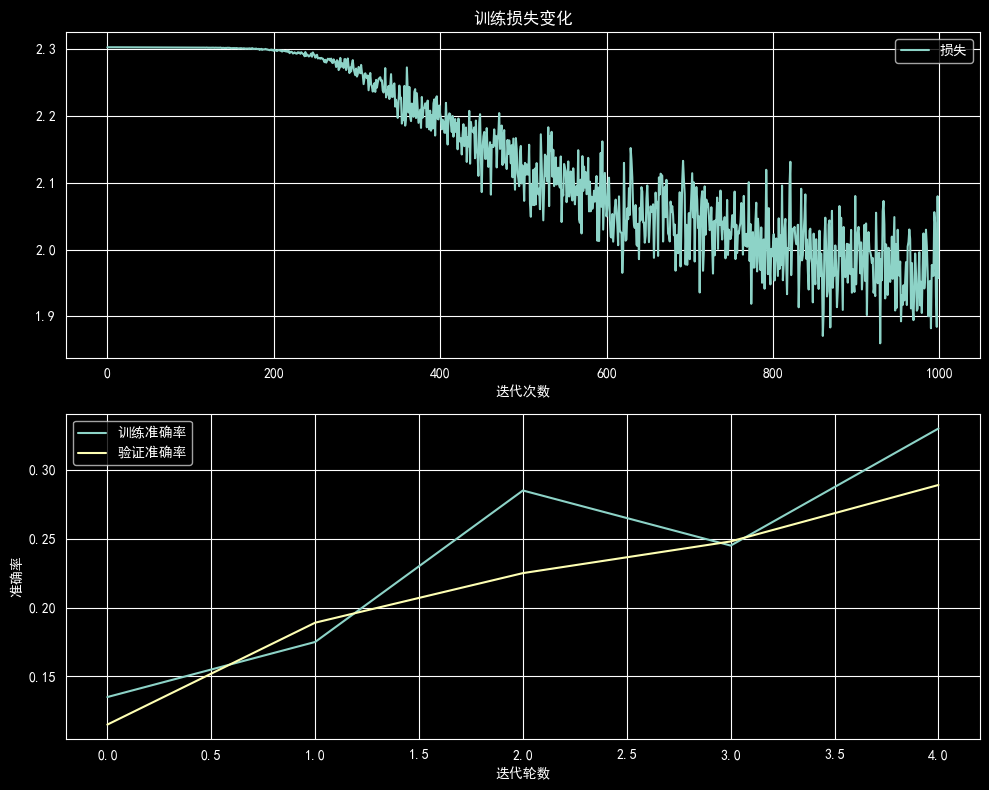

In [9]:
# 绘制损失与准确率变化曲线
plt.subplot(2, 1, 1)
plt.plot(stats['loss_history'], label='损失')
plt.title('训练损失变化')
plt.xlabel('迭代次数')
plt.legend(loc='best')

plt.subplot(2, 1, 2)
plt.plot(stats['train_acc_history'], label='训练准确率')
plt.plot(stats['val_acc_history'], label='验证准确率')
plt.xlabel('迭代轮数')
plt.ylabel('准确率')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

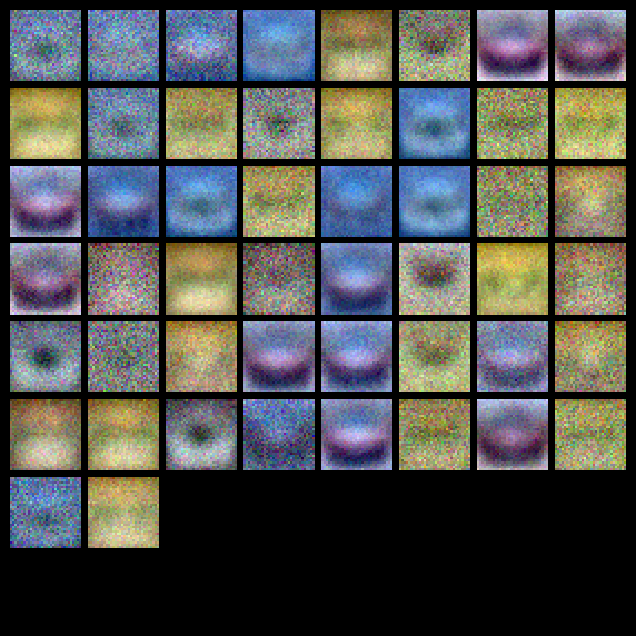

In [10]:
from datasets.vis_utils import visualize_grid

# 可视化网络的权重
def show_net_weights(net):
    W1 = net.params['W1']
    W1 = W1.reshape(32, 32, 3, -1).transpose(3, 0, 1, 2)
    plt.imshow(visualize_grid(W1, padding=3).astype('uint8'))
    plt.gca().axis('off')
    plt.show()

show_net_weights(net)

### 超参数调优分析与实验
从基线训练结果来看，损失呈近似线性下降，说明当前学习率偏低；同时训练集与验证集准确率无明显差距，表明模型容量不足，可通过扩大隐藏层维度提升模型表达能力。若模型容量过大，则会出现过拟合现象，表现为训练集与验证集准确率差距显著扩大。

超参数调优是神经网络调优的核心环节，本次实验遍历隐藏层维度、学习率、训练迭代次数、正则化强度四类超参数，寻找最优配置；学习率衰减可使用默认配置，也可自行调整进一步优化效果。

本次实验验证集准确率目标为45%以上，最优配置可达到50%左右。可自行拓展PCA降维、Dropout正则化、特征工程等优化手段，进一步提升模型效果。

In [11]:
# ====================== 超参数调优：找到最佳模型 ======================
# 【超参数候选列表】可先选少量组合，避免训练时间过长；后续可以逐步扩展
hidden_size_candidates = [800,1000] # 隐藏层神经元数
learning_rate_candidates = [0.001]  # 学习率
reg_candidates = [0.0025]           # 正则化强度（控制过拟合，防止模型记住训练数据噪声）
num_iters_candidates = [10000]      # 迭代次数

# 初始化最佳模型记录变量
best_net = None              # 保存验证集表现最好的模型
best_val_acc = 0.0           # 记录最高验证集准确率
best_params = {}             # 记录最佳超参数组合，方便复盘

# 遍历所有超参数组合，训练+评估模型
for hidden_size in hidden_size_candidates:
    for learning_rate in learning_rate_candidates:
        for reg in reg_candidates:
            for num_iters in num_iters_candidates:
                # 打印当前训练的超参数，方便跟踪进度
                print(f"\n===== 正在训练：hidden_size={hidden_size} | lr={learning_rate} | reg={reg} | iters={num_iters} =====")

                # 初始化模型（输入维度32*32*3=3072，输出10类，std=1e-1和之前保持一致）
                net = TwoLayerNet(input_size=32*32*3, hidden_size=hidden_size, output_size=10, std=1e-1)

                # 训练模型（调用之前写好的train方法）
                stats = net.train(
                    X_train, y_train,    # 训练数据
                    X_val, y_val,        # 验证数据（用来选超参数）
                    learning_rate=learning_rate,
                    learning_rate_decay=0.95,  # 学习率衰减，默认值即可
                    reg=reg,
                    num_iters=num_iters,
                    batch_size=200,      # 批次大小
                    verbose=True         # 打印训练进度，方便看损失变化
                )

                # 计算当前模型在验证集上的准确率
                val_acc = (net.predict(X_val) == y_val).mean()
                print(f"验证集准确率：{val_acc:.4f}")

                # 如果当前模型比之前的更好，更新最佳模型
                if val_acc > best_val_acc:
                    best_val_acc = val_acc
                    best_net = net  # 保存当前模型
                    best_params = {
                        "hidden_size": hidden_size,
                        "learning_rate": learning_rate,
                        "reg": reg,
                        "num_iters": num_iters
                    }
                    print(f"✅ 发现更好的模型！当前最佳验证准确率：{best_val_acc:.4f}")

# 训练结束，打印最终结果
print("\n===== 超参数调优完成 =====")
print(f"最佳验证集准确率：{best_val_acc:.4f}")
print(f"最佳超参数组合：{best_params}")


===== 正在训练：hidden_size=1000 | lr=0.001 | reg=0.0025 | iters=10000 =====
迭代 0/10000: 损失 = inf


D:\Python学习\PythonDL\classifiers\neural_net.py:90: RuntimeWarning: divide by zero encountered in log
  data_loss = np.sum(-np.log(correct_probs)) / N   # 只对每个样本的正确概率取负对数，然后求平均（标量）


迭代 100/10000: 损失 = inf
迭代 200/10000: 损失 = inf
迭代 300/10000: 损失 = inf
迭代 400/10000: 损失 = inf
迭代 500/10000: 损失 = inf
迭代 600/10000: 损失 = inf
迭代 700/10000: 损失 = inf
迭代 800/10000: 损失 = inf
迭代 900/10000: 损失 = inf
迭代 1000/10000: 损失 = inf
迭代 1100/10000: 损失 = inf
迭代 1200/10000: 损失 = inf
迭代 1300/10000: 损失 = inf
迭代 1400/10000: 损失 = inf
迭代 1500/10000: 损失 = 128.3728
迭代 1600/10000: 损失 = 152.3511
迭代 1700/10000: 损失 = inf
迭代 1800/10000: 损失 = inf
迭代 1900/10000: 损失 = inf
迭代 2000/10000: 损失 = inf
迭代 2100/10000: 损失 = inf
迭代 2200/10000: 损失 = 103.1453
迭代 2300/10000: 损失 = inf
迭代 2400/10000: 损失 = 109.0757
迭代 2500/10000: 损失 = 119.8751
迭代 2600/10000: 损失 = 106.6313
迭代 2700/10000: 损失 = 102.7994
迭代 2800/10000: 损失 = 107.1940
迭代 2900/10000: 损失 = 116.0762
迭代 3000/10000: 损失 = 76.5199
迭代 3100/10000: 损失 = 95.3992
迭代 3200/10000: 损失 = 87.9201
迭代 3300/10000: 损失 = 80.0491
迭代 3400/10000: 损失 = 74.7929
迭代 3500/10000: 损失 = 98.6145
迭代 3600/10000: 损失 = 63.4072
迭代 3700/10000: 损失 = 79.6832
迭代 3800/10000: 损失 = 74.6068
迭代 3900/10000: 损

Failed to read module file 'D:\Python学习\PythonDL\classifiers\neural_net.py' for module 'classifiers.neural_net': UnicodeDecodeError
Traceback (most recent call last):
  File "D:\Python解释器\.venv\Lib\site-packages\IPython\extensions\deduperreload\deduperreload.py", line 556, in maybe_reload_module
    new_source_code = f.read()
UnicodeDecodeError: 'gbk' codec can't decode byte 0x80 in position 96: illegal multibyte sequence


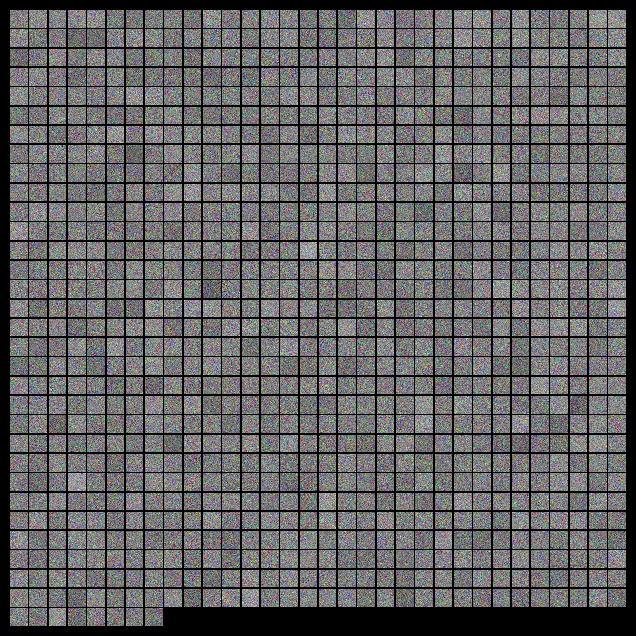

In [12]:
# 可视化最优模型第一层权重
from datasets.vis_utils import visualize_grid

def show_net_weights(net):
    """
    可视化第一层权重（W1），把高维权重还原成图像形式
    输入：model - 训练好的TwoLayerNet模型
    """
    # 取出第一层权重 W1，形状是 (3072, hidden_size)
    W1 = net.params["W1"]

    # 把3072维输入 reshape 成 32×32×3（对应CIFAR-10图像尺寸）
    # 再把 hidden_size 放到最前面，方便把每个隐藏单元的权重拼成网格
    W1 = W1.reshape(32, 32, 3, -1).transpose(3, 0, 1, 2)

    # 用 visualize_grid 把多张权重图拼成一张网格图，padding=3 是图之间的间距
    grid = visualize_grid(W1, padding=3).astype("uint8")

    # 显示图像，隐藏坐标轴（更干净）
    plt.imshow(grid)
    plt.gca().axis("off")
    plt.show()

# 调用函数，可视化最佳模型的第一层权重
show_net_weights(best_net)

### 测试集性能评估
使用最优超参数配置的模型在测试集上进行最终性能评估，目标准确率不低于45%。

In [13]:
# 测试集模型性能评估
# 用最佳模型在测试集上预测，计算准确率
test_acc = (best_net.predict(X_test) == y_test).mean()
print(f"\n===== 测试集评估 =====")
print(f"测试集准确率：{test_acc:.4f}")


===== 测试集评估 =====
测试集准确率：0.4600


### 过拟合现象与优化方案分析
测试集准确率显著低于训练集，是典型的过拟合表现：模型过度拟合训练集的噪声与细节，泛化能力下降。常见优化方案分析如下：
1. **扩大训练数据集**：更多训练数据可让模型学习到更通用的特征规律，降低对训练集噪声的依赖，提升泛化能力，缩小训练与测试的精度差距。
2. **增加隐藏层单元**：会提升模型容量与复杂度，加剧过拟合，进一步扩大训练与测试的精度差距，无法解决问题。
3. **增强正则化强度**：L2正则、Dropout等正则化手段可限制模型复杂度，避免过度记忆训练噪声，强制模型学习泛化性更强的特征，是缓解过拟合的经典方案。